# Project 1

In [87]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

In [88]:
class Calculations:
    def __init__(self, S, K, T, r, sigma):
        self.S = S
        self.K = K
        self.T = T
        self.r = r
        self.sigma = sigma

    def d1(self):
        return (np.log(self.S / self.K) + (self.r + 0.5 * self.sigma**2) * self.T) / (self.sigma * np.sqrt(self.T))
    
    def d2(self):
        return self.d1() - self.sigma * np.sqrt(self.T)

    def delta(self):
        return norm.cdf(self.d1())
    
    def gamma(self):
        return norm.pdf(self.d1()) / (self.S * self.sigma * np.sqrt(self.T))

In [89]:
df = pd.read_excel('Datos AAPL proyecto cuanti.xlsx', sheet_name='Hoja2')
df_filtered = df.head(10)

df_filtered


,Contract Name,Last Trade Date (EST),Strike,Last Price,Bid,Ask,Change,% Change,Volume,Open Interest,Implied Volatility,Type,Date,Price
0,AAPL260515C00185000,1/20/2026 3:20 PM,185,65.07,65.75,67.55,0.00,0.0000,1,107,0.4919,Calls,2026-01-22,248.35
1,AAPL260515C00195000,1/21/2026 11:34 AM,195,56.00,56.95,57.55,0.00,0.0000,15,198,0.4271,Calls,2026-01-22,248.35
2,AAPL260515C00215000,1/21/2026 12:24 PM,215,40.90,39.50,40.05,2.70,0.0707,20,58,0.3681,Calls,2026-01-22,248.35
3,AAPL260515C00225000,1/22/2026 1:28 PM,225,33.85,31.55,32.05,3.30,0.1080,26,144,0.3437,Calls,2026-01-22,248.35
4,AAPL260515C00240000,1/22/2026 3:28 PM,240,21.40,21.15,21.40,0.75,0.0363,55,5638,0.3121,Calls,2026-01-22,248.35
5,AAPL260515C00250000,1/22/2026 3:56 PM,250,15.45,15.35,15.55,0.15,0.0098,566,3446,0.2961,Calls,2026-01-22,248.35
6,AAPL260515C00265000,1/22/2026 3:58 PM,265,8.75,8.65,8.85,-0.05,-0.0057,129,1174,0.2776,Calls,2026-01-22,248.35
7,AAPL260515C00275000,1/22/2026 3:55 PM,275,5.78,5.65,5.75,0.18,0.0321,262,1771,0.2687,Calls,2026-01-22,248.35
8,AAPL260515C00295000,1/22/2026 1:14 PM,295,2.52,2.24,2.48,0.30,0.1351,149,1018,0.2680,Calls,2026-01-22,248.35
9,AAPL260515C00305000,1/22/2026 3:16 PM,305,1.53,1.41,1.65,0.08,0.0552,46,409,0.2711,Calls,2026-01-22,248.35


In [90]:
strikes = df_filtered['Strike'].tolist()
last_prices = df_filtered['Last Price'].tolist()
prices_df = pd.read_excel('Datos AAPL proyecto cuanti.xlsx', sheet_name='Hoja3')

In [91]:
prices_df['Remaining_Time'] = (pd.Timestamp('2026-04-09') - prices_df['Date']).dt.days
prices_df['Remaining_Time'] = prices_df['Remaining_Time'].replace(0, 0.0001)
prices_df['T_Years'] = prices_df['Remaining_Time'] / 365
sigma = prices_df['Price'].pct_change().std() * (252 ** 0.5)
prices_df['Sigma_Fixed'] = sigma
prices_df['R_Cont'] = 0.0426
last_price = prices_df['Price'].iloc[-1]
prices_df

,Date,Price,Remaining_Time,T_Years,Sigma_Fixed,R_Cont
0,2026-01-22,248.35,77.0000,2.109589e-01,0.384354,0.0426
1,2026-01-27,258.27,72.0000,1.972603e-01,0.384354,0.0426
2,2026-01-29,258.28,70.0000,1.917808e-01,0.384354,0.0426
3,2026-02-03,269.48,65.0000,1.780822e-01,0.384354,0.0426
4,2026-02-05,275.91,63.0000,1.726027e-01,0.384354,0.0426
5,2026-02-10,273.68,58.0000,1.589041e-01,0.384354,0.0426
6,2026-02-12,261.73,56.0000,1.534247e-01,0.384354,0.0426
7,2026-02-17,263.88,51.0000,1.397260e-01,0.384354,0.0426
8,2026-02-19,260.58,49.0000,1.342466e-01,0.384354,0.0426
9,2026-02-24,272.14,44.0000,1.205479e-01,0.384354,0.0426


# Scenario 1: No hedging

In [92]:
gain_loss = [-max(last_price - strike, 0) for strike in strikes]
option_excercised = [last_price > strike for strike in strikes]
option_excercised = [1 if exercised else 0 for exercised in option_excercised]
results_df = pd.DataFrame({
    'Strike': strikes,
    'Last Price': last_prices,
    'Gain/Loss': gain_loss,
    'Option Exercised': option_excercised
})
stocks_to_buy = results_df['Option Exercised'].sum()
total_premiums = sum(last_prices) * np.exp(prices_df['R_Cont'].iloc[0] * prices_df['T_Years'].iloc[0])
buy = stocks_to_buy * last_price
sell = sum([strike * exercised for strike, exercised in zip(strikes, option_excercised)])
total_scenario_1 = - buy + sell + total_premiums
print(f"Total PnL for Scenario 1 (without hedging): {total_scenario_1:.2f} $")

Total PnL for Scenario 1 (without hedging): 0.58 $


# Scenario 2: Delta Hedging

In [93]:
df_delta = pd.DataFrame({'Strike': strikes})

for _, row in prices_df.iterrows():
    col_name = row['Date'].date().strftime('%m-%d')
    df_delta[col_name] = df_delta['Strike'].apply(
        lambda K: Calculations(
            S=row['Price'],
            K=K,
            T=row['T_Years'],
            r=row['R_Cont'],
            sigma=row['Sigma_Fixed']
        ).delta()
    )

total_delta = df_delta.drop(columns=['Strike']).sum()
delta_diff = total_delta.diff().fillna(total_delta.iloc[0])
delta_times_s = delta_diff * prices_df['Price'].to_list()
commission = abs(0.005 * delta_times_s)

total_gain_loss = (delta_times_s + commission).cumsum()
buy = total_gain_loss.iloc[-1]
sell = sum([strike * exercised for strike, exercised in zip(strikes, option_excercised)])
total_scenario_2 = - buy + sell + total_premiums
print(f"Total PnL for Scenario 2 (with delta hedging): {total_scenario_2:.2f} $")

Total PnL for Scenario 2 (with delta hedging): 34.76 $


# Scenario 3: Delta-Gamma Hedging

In [94]:
df_gamma = pd.DataFrame({'Strike': strikes})

for _, row in prices_df.iterrows():
    col_name = row['Date'].date().strftime('%m-%d')
    df_gamma[col_name] = df_gamma['Strike'].apply(
        lambda K: Calculations(
            S=row['Price'],
            K=K,
            T=row['T_Years'],
            r=row['R_Cont'],
            sigma=row['Sigma_Fixed']
        ).gamma()
    )

total_gamma = df_gamma.drop(columns=['Strike']).sum()
threshold_1 = 0.1
threshold_2 = 0.08
added_subs = 0.1

new_delta = [
    total_delta.iloc[i] * (1 + added_subs) if total_gamma.iloc[i] > threshold_1
    else total_delta.iloc[i] * (1 - added_subs) if total_gamma.iloc[i] < threshold_2
    else total_delta.iloc[i]
    for i in range(len(total_gamma))
]
new_delta = pd.Series(new_delta)
delta_gamma_diff = new_delta.diff().fillna(new_delta.iloc[0])
delta_gamma_times_s = delta_gamma_diff * prices_df['Price'].to_list()
commission = abs(0.005 * delta_gamma_times_s)

total_gain_loss = (delta_gamma_times_s + commission).cumsum()
buy = total_gain_loss.iloc[-1]
sell = sum([strike * exercised for strike, exercised in zip(strikes, option_excercised)])
total_scenario_3 = - buy + sell + total_premiums
print(f"Total PnL for Scenario 3 (with delta-gamma hedging): {total_scenario_3:.2f} $")


Total PnL for Scenario 3 (with delta-gamma hedging): 187.64 $


# Scenario 1.2: No hedging with Simulation for St

In [102]:
n_simulations = 1000
n_days = len(prices_df)
mu = prices_df['Price'].pct_change().mean() * 252  
sigma = prices_df['Sigma_Fixed'].iloc[-1]
dt = 1/252
first_price = prices_df['Price'].iloc[0]
S0 = first_price

np.random.seed(42)
W = np.random.normal(0, 1, (n_simulations, n_days))
daily_returns = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * W)

paths = np.zeros((n_simulations, n_days + 1))
paths[:, 0] = S0
for t in range(1, n_days + 1):
    paths[:, t] = paths[:, t-1] * daily_returns[:, t-1]

final_prices = paths[:, -1]

total_pnl = []

for St in final_prices:
    gain_loss = [-max(St - strike, 0) for strike in strikes]
    option_exercised = [1 if St > strike else 0 for strike in strikes]
    
    last_prices_sim = [St] * len(strikes)  
    total_premiums = sum(last_prices) * np.exp(prices_df['R_Cont'].iloc[0] * prices_df['T_Years'].iloc[0])
    buy = sum(option_exercised) * St
    sell = sum([strike * ex for strike, ex in zip(strikes, option_exercised)])
    
    pnl = - buy + sell + total_premiums
    total_pnl.append(pnl)

total_pnl_scenario1 = np.array(total_pnl)
print(f"Mean PnL: {total_pnl_scenario1.mean():.2f} $")
print(f"Std PnL:  {total_pnl_scenario1.std():.2f} $")
print(f"Min PnL:  {total_pnl_scenario1.min():.2f} $")
print(f"Max PnL:  {total_pnl_scenario1.max():.2f} $")

Mean PnL: -45.52 $
Std PnL:  194.27 $
Min PnL:  -1046.63 $
Max PnL:  253.52 $


# Scenario 2.2: Delta hedging with Simulation for St

In [103]:
total_pnl_scenario2 = []

for path in paths: 
    simulated_prices = path[1:]  
    St = path[-1]  
    df_delta_sim = pd.DataFrame({'Strike': strikes})

    for i, row in prices_df.iterrows():
        col_name = row['Date'].date().strftime('%m-%d')
        S_sim = simulated_prices[i]
        df_delta_sim[col_name] = df_delta_sim['Strike'].apply(
            lambda K: Calculations(
                S=S_sim,
                K=K,
                T=row['T_Years'],
                r=row['R_Cont'],
                sigma=row['Sigma_Fixed']
            ).delta()
        )

    total_delta_sim = df_delta_sim.drop(columns=['Strike']).sum()
    delta_diff_sim = total_delta_sim.diff().fillna(total_delta_sim.iloc[0])
    delta_times_s_sim = delta_diff_sim * simulated_prices
    commission_sim = abs(0.005 * delta_times_s_sim)

    total_gain_loss_sim = (delta_times_s_sim + commission_sim).cumsum()
    buy_sim = total_gain_loss_sim.iloc[-1]

    option_exercised_sim = [1 if St > strike else 0 for strike in strikes]
    sell_sim = sum([strike * ex for strike, ex in zip(strikes, option_exercised_sim)])
    total_premiums_sim = sum(last_prices) * np.exp(prices_df['R_Cont'].iloc[0] * prices_df['T_Years'].iloc[0])

    pnl = - buy_sim + sell_sim + total_premiums_sim
    total_pnl_scenario2.append(pnl)

total_pnl_scenario2 = np.array(total_pnl_scenario2)
print(f"Mean PnL Scenario 2: {total_pnl_scenario2.mean():.2f} $")
print(f"Std PnL Scenario 2:  {total_pnl_scenario2.std():.2f} $")
print(f"Min PnL Scenario 2:  {total_pnl_scenario2.min():.2f} $")
print(f"Max PnL Scenario 2:  {total_pnl_scenario2.max():.2f} $")

Mean PnL Scenario 2: 23.89 $
Std PnL Scenario 2:  37.29 $
Min PnL Scenario 2:  -189.54 $
Max PnL Scenario 2:  129.44 $


# Scenario 3.2: Delta-Gamma hedging with Simulation for St

In [104]:
total_pnl_scenario3 = []
threshold_1 = 0.1
threshold_2 = 0.08
added_subs = 0.1

for path in paths:
    simulated_prices = path[1:] 
    St = path[-1]

    df_delta_sim = pd.DataFrame({'Strike': strikes})
    df_gamma_sim = pd.DataFrame({'Strike': strikes})

    for i, row in prices_df.iterrows():
        col_name = row['Date'].date().strftime('%m-%d')
        S_sim = simulated_prices[i]

        df_delta_sim[col_name] = df_delta_sim['Strike'].apply(
            lambda K: Calculations(
                S=S_sim, K=K, T=row['T_Years'],
                r=row['R_Cont'], sigma=row['Sigma_Fixed']
            ).delta()
        )
        df_gamma_sim[col_name] = df_gamma_sim['Strike'].apply(
            lambda K: Calculations(
                S=S_sim, K=K, T=row['T_Years'],
                r=row['R_Cont'], sigma=row['Sigma_Fixed']
            ).gamma()
        )

    total_delta_sim = df_delta_sim.drop(columns=['Strike']).sum()
    total_gamma_sim = df_gamma_sim.drop(columns=['Strike']).sum()

    new_delta_sim = [
        total_delta_sim.iloc[i] * (1 + added_subs) if total_gamma_sim.iloc[i] > threshold_1
        else total_delta_sim.iloc[i] * (1 - added_subs) if total_gamma_sim.iloc[i] < threshold_2
        else total_delta_sim.iloc[i]
        for i in range(len(total_gamma_sim))
    ]

    new_delta_sim = pd.Series(new_delta_sim)
    delta_gamma_diff_sim = new_delta_sim.diff().fillna(new_delta_sim.iloc[0])
    delta_gamma_times_s_sim = delta_gamma_diff_sim * simulated_prices
    commission_sim = abs(0.005 * delta_gamma_times_s_sim)

    total_gain_loss_sim = (delta_gamma_times_s_sim + commission_sim).cumsum()
    buy_sim = total_gain_loss_sim.iloc[-1]

    option_exercised_sim = [1 if St > strike else 0 for strike in strikes]
    sell_sim = sum([strike * ex for strike, ex in zip(strikes, option_exercised_sim)])
    total_premiums_sim = sum(last_prices) * np.exp(prices_df['R_Cont'].iloc[0] * prices_df['T_Years'].iloc[0])

    pnl = - buy_sim + sell_sim + total_premiums_sim
    total_pnl_scenario3.append(pnl)

total_pnl_scenario3 = np.array(total_pnl_scenario3)
print(f"Mean PnL Scenario 3: {total_pnl_scenario3.mean():.2f} $")
print(f"Std PnL Scenario 3:  {total_pnl_scenario3.std():.2f} $")
print(f"Min PnL Scenario 3:  {total_pnl_scenario3.min():.2f} $")
print(f"Max PnL Scenario 3:  {total_pnl_scenario3.max():.2f} $")

Mean PnL Scenario 3: 179.59 $
Std PnL Scenario 3:  82.90 $
Min PnL Scenario 3:  -511.93 $
Max PnL Scenario 3:  336.63 $


# Visualizaciones

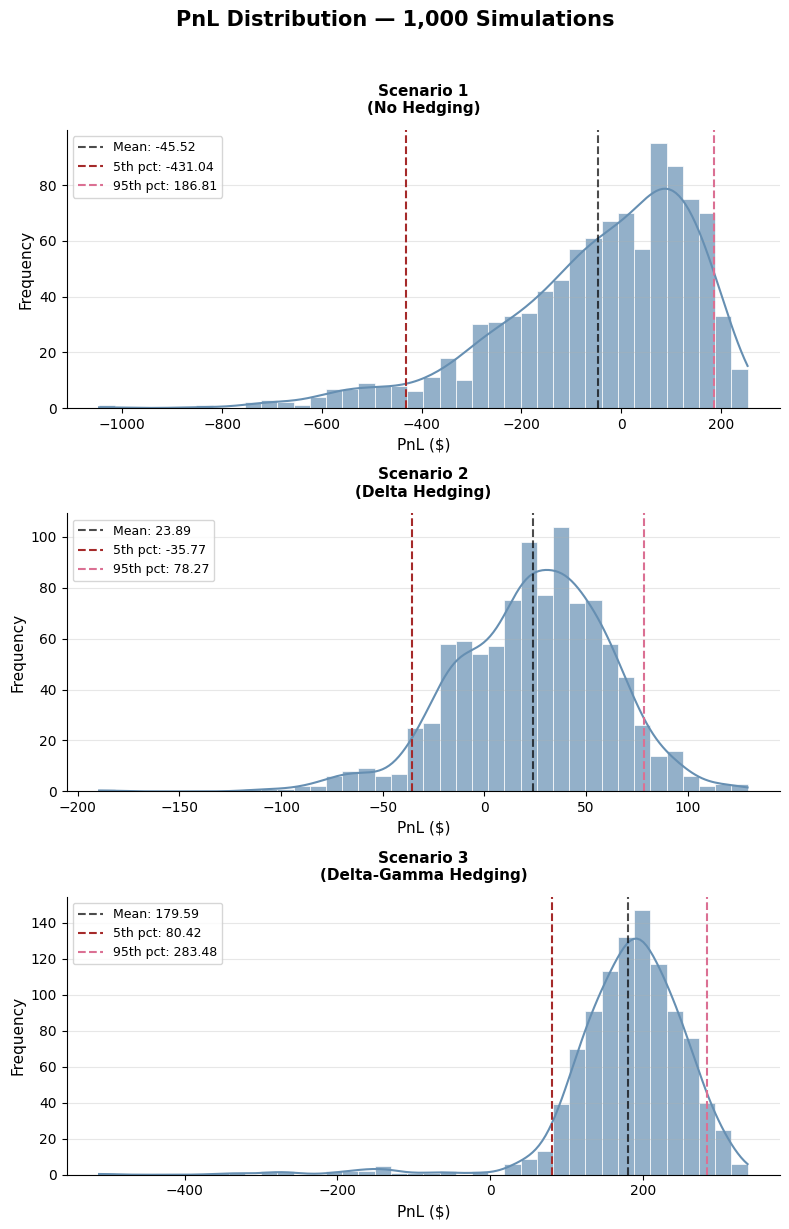

In [105]:
fig, axes = plt.subplots(3, 1, figsize=(8, 12))

scenarios = [
    (total_pnl_scenario1, 'Scenario 1\n(No Hedging)', '#668fb2'),
    (total_pnl_scenario2, 'Scenario 2\n(Delta Hedging)', '#668fb2'),
    (total_pnl_scenario3, 'Scenario 3\n(Delta-Gamma Hedging)', '#668fb2')
]

for ax, (data, title, color) in zip(axes, scenarios):
    sns.histplot(data, bins=40, ax=ax, color=color, alpha=0.7, edgecolor='white', linewidth=0.5, kde=True)
    ax.axvline(data.mean(), color='black', linestyle='--', alpha=0.7, linewidth=1.5, label=f'Mean: {data.mean():,.2f}')
    ax.axvline(np.percentile(data, 5), color='brown', linestyle='--', linewidth=1.5, label=f'5th pct: {np.percentile(data, 5):,.2f}')
    ax.axvline(np.percentile(data, 95), color='palevioletred', linestyle='--', linewidth=1.5, label=f'95th pct: {np.percentile(data, 95):,.2f}')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=12)
    ax.set_xlabel('PnL ($)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    sns.despine(ax=ax)

fig.suptitle('PnL Distribution — 1,000 Simulations', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

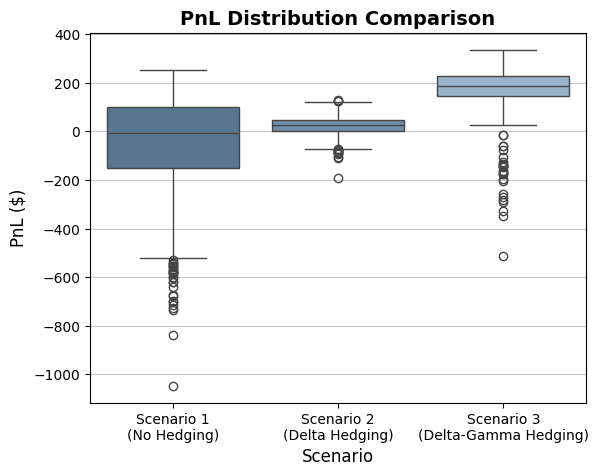

In [106]:
sns.boxplot(data=[total_pnl_scenario1, total_pnl_scenario2, total_pnl_scenario3], palette=['#507699', '#668fb2', '#90B2D1'])
plt.grid(axis='y', alpha=0.7)
plt.title('PnL Distribution Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Scenario', fontsize=12)
plt.ylabel('PnL ($)', fontsize=12)
plt.xticks([0, 1, 2], ['Scenario 1\n(No Hedging)', 'Scenario 2\n(Delta Hedging)', 'Scenario 3\n(Delta-Gamma Hedging)'])
plt.show()

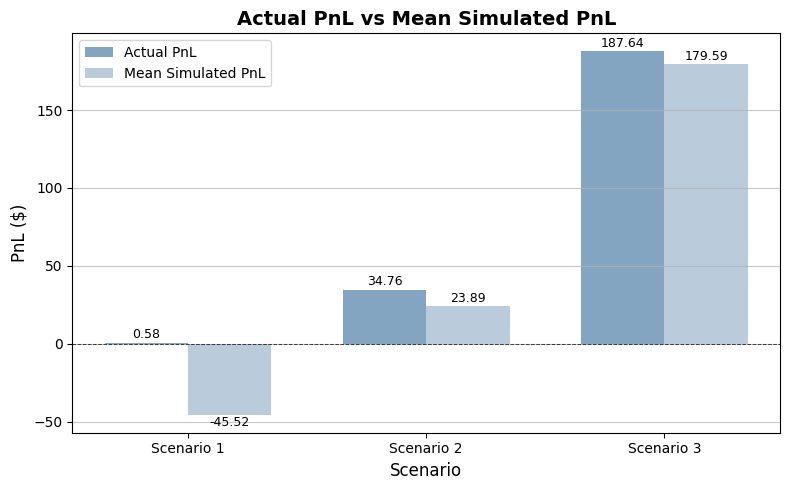

In [123]:
actual_pnls = [total_scenario_1, total_scenario_2, total_scenario_3]
mean_pnls = [total_pnl_scenario1.mean(), total_pnl_scenario2.mean(), total_pnl_scenario3.mean()]

labels = ['Scenario 1', 'Scenario 2', 'Scenario 3']
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))
bars1 = plt.bar(x - width/2, actual_pnls, width=width, color=['#668fb2', '#668fb2', '#668fb2'], alpha=0.8, label='Actual PnL')
bars2 = plt.bar(x + width/2, mean_pnls, width=width, color=['#668fb2', '#668fb2', '#668fb2'], alpha=0.45, label='Mean Simulated PnL')

plt.bar_label(bars1, fmt='%.2f', padding=1, fontsize=9)
plt.bar_label(bars2, fmt='%.2f', padding=1, fontsize=9)

plt.title('Actual PnL vs Mean Simulated PnL', fontsize=14, fontweight='bold')
plt.xlabel('Scenario', fontsize=12)
plt.ylabel('PnL ($)', fontsize=12)
plt.grid(axis='y', alpha=0.7)
plt.axhline(0, color='black', linestyle='--', linewidth=0.7, alpha=0.7)
plt.xticks(x, labels)
plt.legend()
plt.tight_layout()
plt.show()

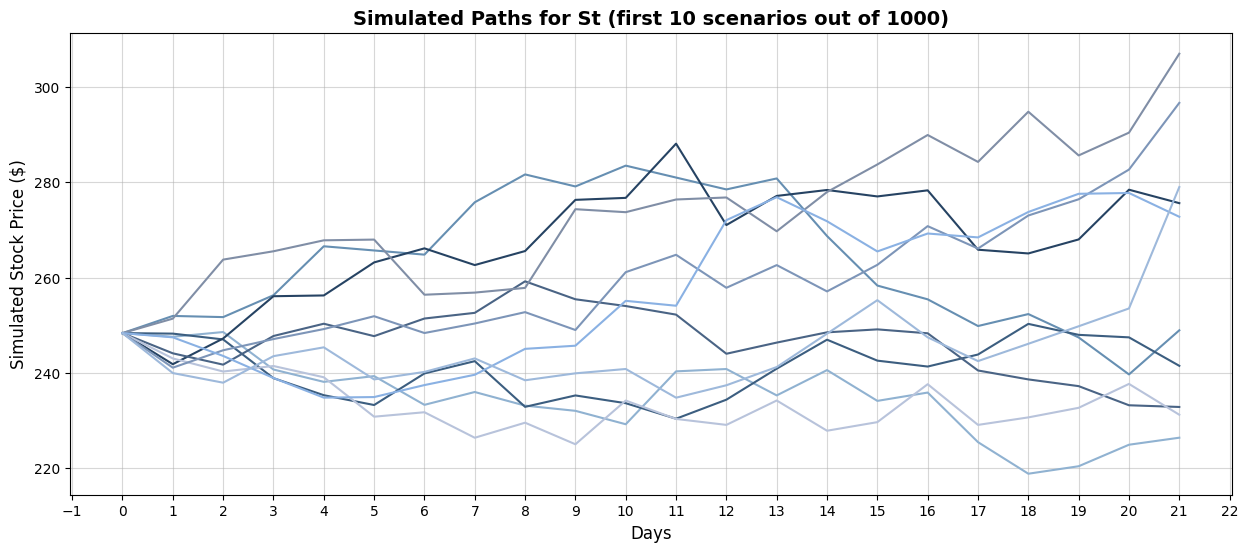

In [107]:
plt.figure(figsize=(15, 6))
colors_blue = ['#668fb2', '#90B2D1', '#3C5E80', '#264363', '#4A6485', '#808EA6', '#B8C3DB', '#7D95B8', '#8AB1E3', '#9EB9DB']

for i in range(10):
    plt.plot(paths[i], color=colors_blue[i])

plt.gca().xaxis.set_major_locator(MultipleLocator(1)) 
plt.title('Simulated Paths for St (first 10 scenarios out of 1000)', fontsize=14, fontweight='bold')
plt.xlabel('Days', fontsize=12)
plt.ylabel('Simulated Stock Price ($)', fontsize=12)
plt.grid(alpha=0.5)
plt.show()